# Librerias

In [1]:
import pandas as pd
import tensorflow as tf
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow_decision_forests as tfdf
import numpy as np
import keras
import seaborn as sns
from keras import layers
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency, chi2 as chi2_dist
from sklearn.metrics import mean_absolute_error


print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Built with CUDA:", tf.test.is_built_with_cuda())

2026-05-16 18:47:11.382186: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 18:47:11.397858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778971631.417480   46910 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778971631.422899   46910 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778971631.439616   46910 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Num GPUs Available:  0
Built with CUDA: True


W0000 00:00:1778971637.548753   46910 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
df = pd.read_csv('Datos/dataset_airbnb_procesado.csv')
#df = df.dropna()
df = df.drop(['id'], axis = 1)

In [ ]:
columnas_criticas =['price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_ltm']

for col in columnas_criticas:
    df[col] = np.log1p(df[col])

print("\n--- VALORES NUEVOS (Después del logaritmo) ---")
for col in columnas_criticas:
    print(f"{col.upper()}: Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurt():.2f}")

In [ ]:
df.head()

# Analisis exploratorio de los datos

In [4]:
stats_df = df.describe(include='object').T
print("Estadísticas descriptivas:")
display(stats_df)

print("\nObservaciones duplicadas:", df.duplicated().sum())
print("Valores nulos por columna:")
print(df.isnull().sum())

Estadísticas descriptivas:


/tmp/ipykernel_46910/1774689201.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  stats_df = df.describe(include='object').T


,count,unique,top,freq
neighbourhood,160069,30,Santiago,60685
room_type,160069,4,Entire home/apt,124147
archivo_fecha_origen,160069,19,2025-08-29,12208
nombre_estacion,160069,121,Manquehue,10960
fecha_inauguracion_metro,160069,24,1980-08-31,33728



Observaciones duplicadas: 45
Valores nulos por columna:
neighbourhood               0
latitude                    0
longitude                   0
room_type                   0
price                       0
minimum_nights              0
number_of_reviews           0
availability_365            0
number_of_reviews_ltm       0
archivo_fecha_origen        0
Dólar                       0
nombre_estacion             0
fecha_inauguracion_metro    0
pax_internacional           0
pax_nacional                0
pax_total                   0
pax_total_var_pct           0
pax_total_ma3               0
alojamiento                 0
comida_fuera                0
gas_licuado                 0
mantencion_hogar            0
parafina                    0
taxi                        0
dtype: int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 160069 entries, 0 to 160068
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   neighbourhood             160069 non-null  str    
 1   latitude                  160069 non-null  float64
 2   longitude                 160069 non-null  float64
 3   room_type                 160069 non-null  str    
 4   price                     160069 non-null  float64
 5   minimum_nights            160069 non-null  float64
 6   number_of_reviews         160069 non-null  float64
 7   availability_365          160069 non-null  int64  
 8   number_of_reviews_ltm     160069 non-null  float64
 9   archivo_fecha_origen      160069 non-null  str    
 10  Dólar                     160069 non-null  int64  
 11  nombre_estacion           160069 non-null  str    
 12  fecha_inauguracion_metro  160069 non-null  str    
 13  pax_internacional         160069 non-null  int64  
 14 

## Histogramas

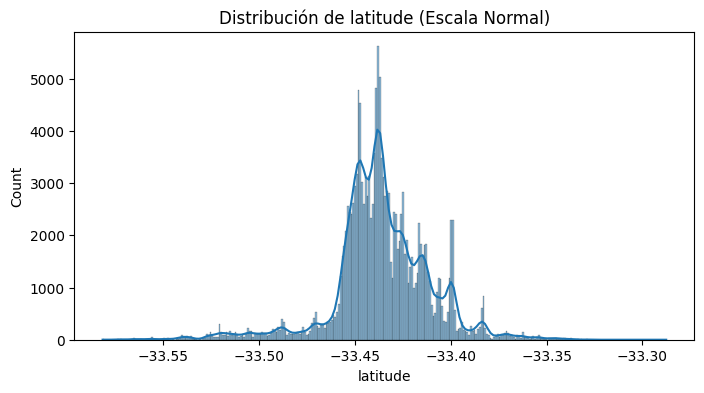

latitude - skewness> -0.56
latitude - Kurtosis> 3.27
------------------------------


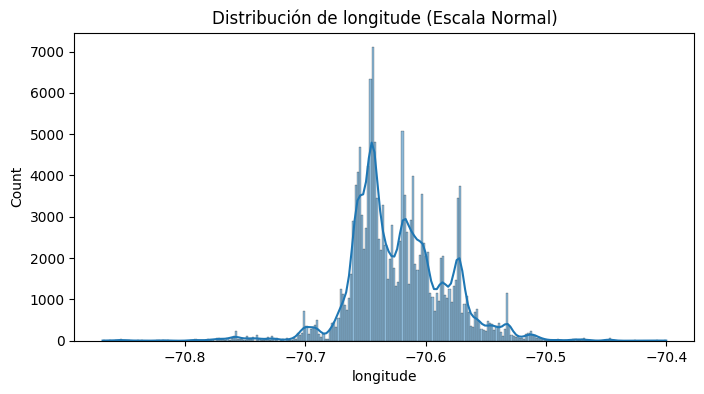

longitude - skewness> 0.03
longitude - Kurtosis> 2.48
------------------------------


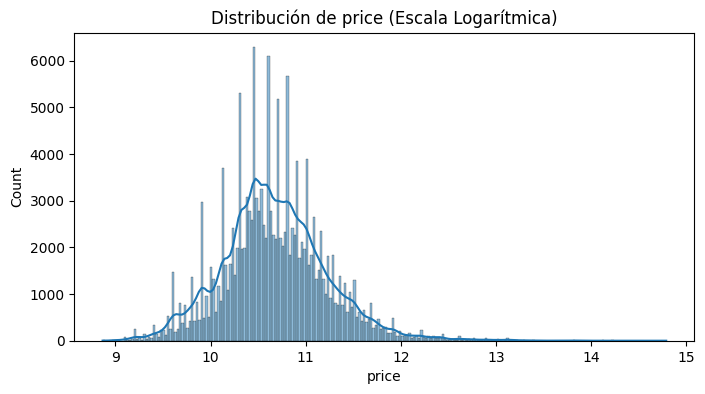

price - skewness> 0.53
price - Kurtosis> 1.60
------------------------------


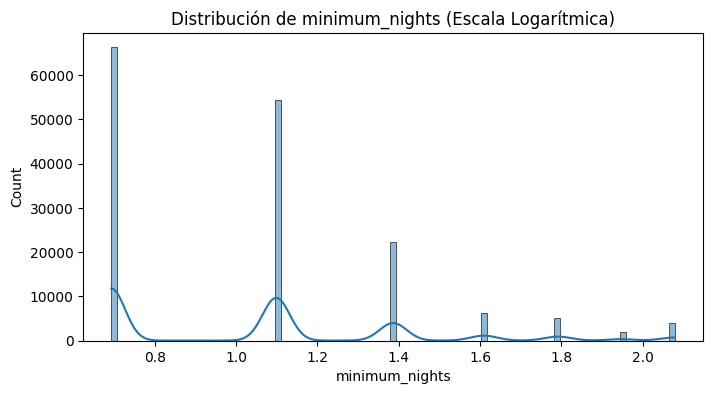

minimum_nights - skewness> 0.87
minimum_nights - Kurtosis> 0.20
------------------------------


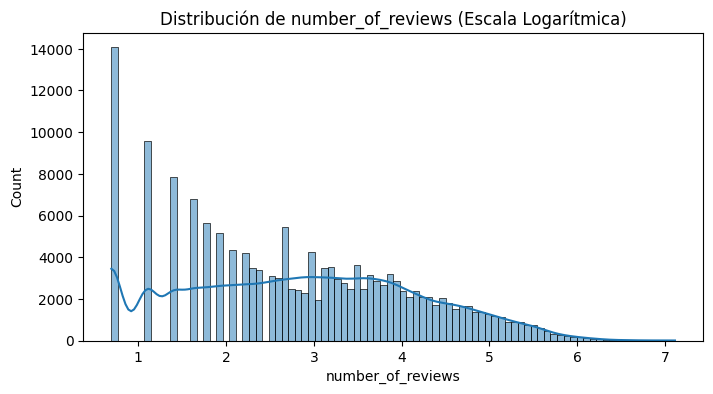

number_of_reviews - skewness> 0.15
number_of_reviews - Kurtosis> -0.81
------------------------------


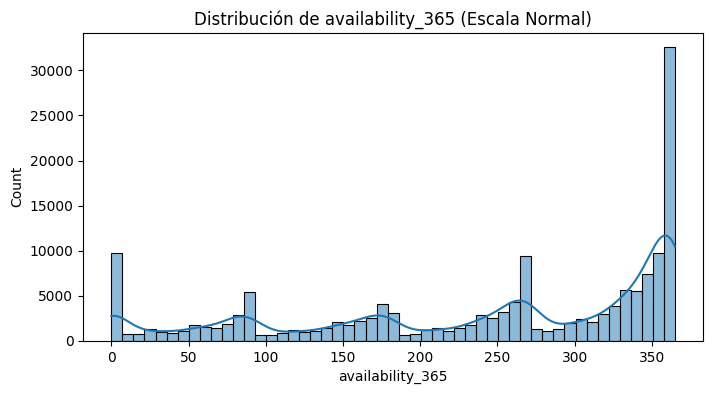

availability_365 - skewness> -0.70
availability_365 - Kurtosis> -0.85
------------------------------


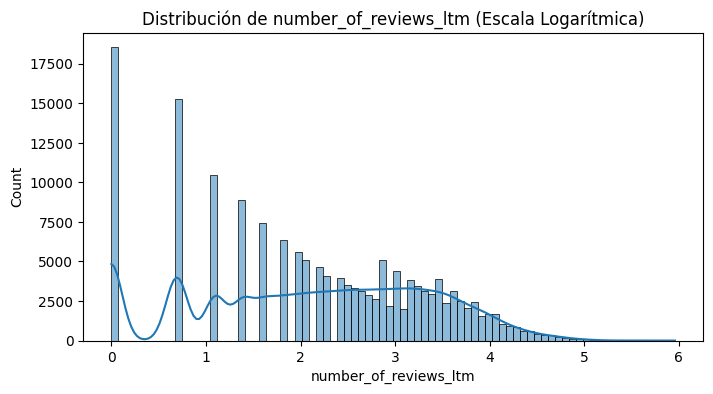

number_of_reviews_ltm - skewness> -0.12
number_of_reviews_ltm - Kurtosis> -0.95
------------------------------


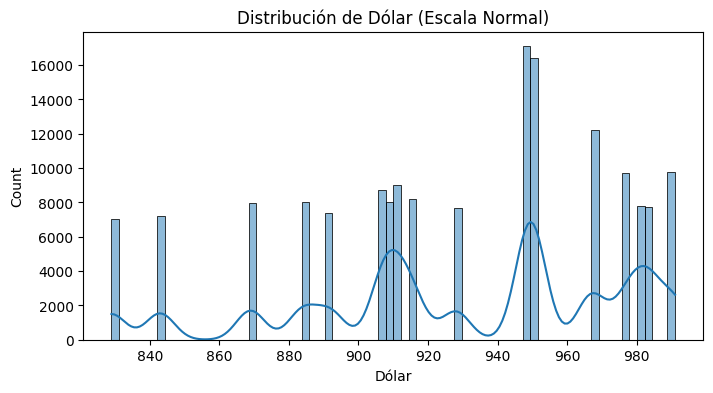

Dólar - skewness> -0.53
Dólar - Kurtosis> -0.60
------------------------------


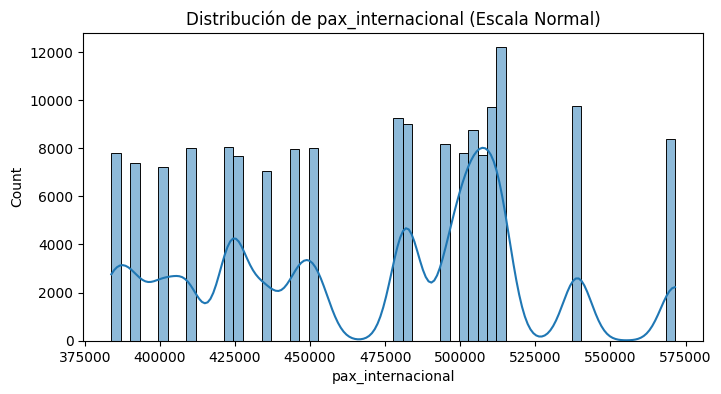

pax_internacional - skewness> -0.06
pax_internacional - Kurtosis> -0.97
------------------------------


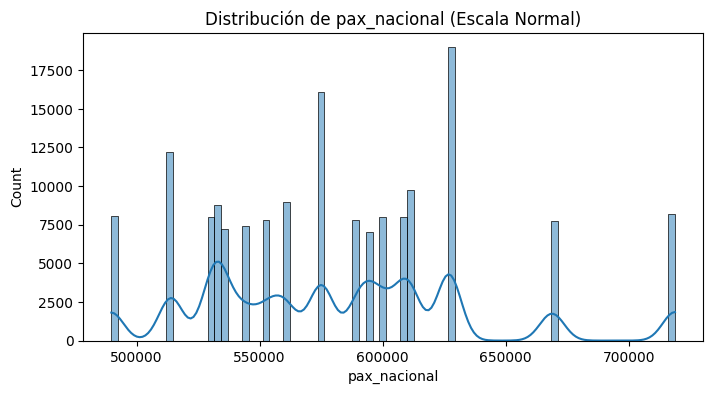

pax_nacional - skewness> 0.61
pax_nacional - Kurtosis> 0.19
------------------------------


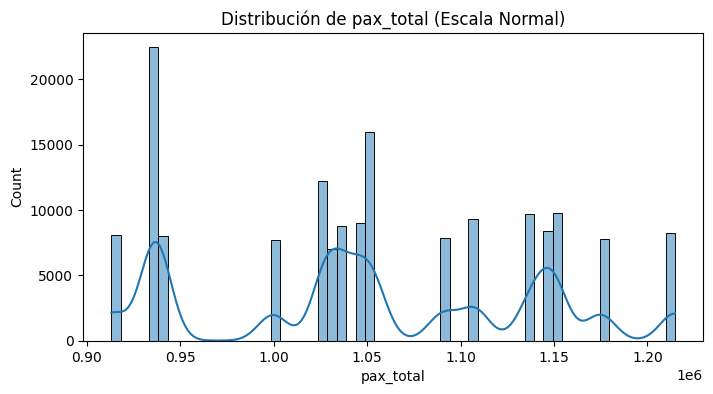

pax_total - skewness> 0.04
pax_total - Kurtosis> -1.01
------------------------------


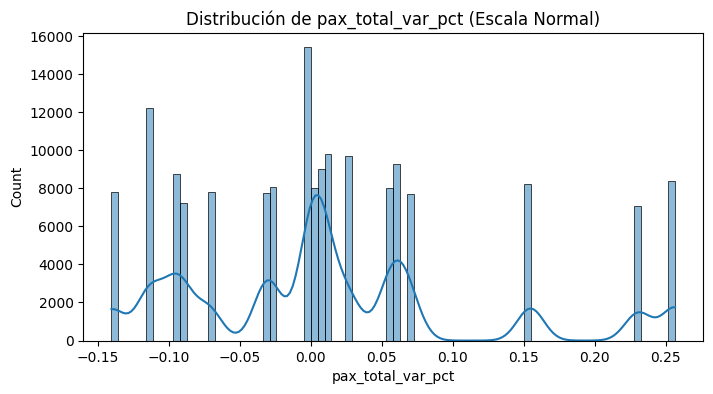

pax_total_var_pct - skewness> 0.82
pax_total_var_pct - Kurtosis> 0.24
------------------------------


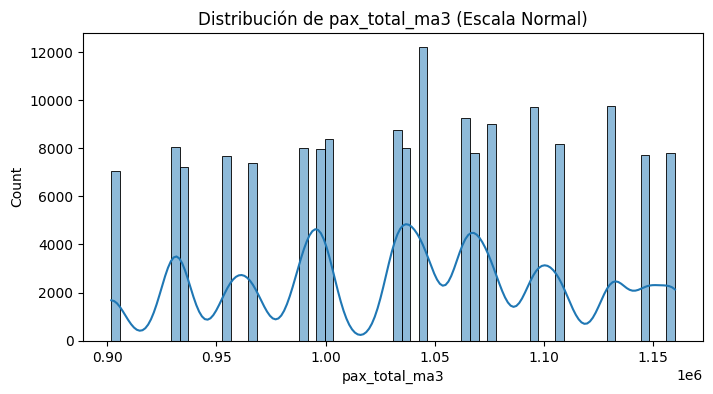

pax_total_ma3 - skewness> -0.09
pax_total_ma3 - Kurtosis> -0.94
------------------------------


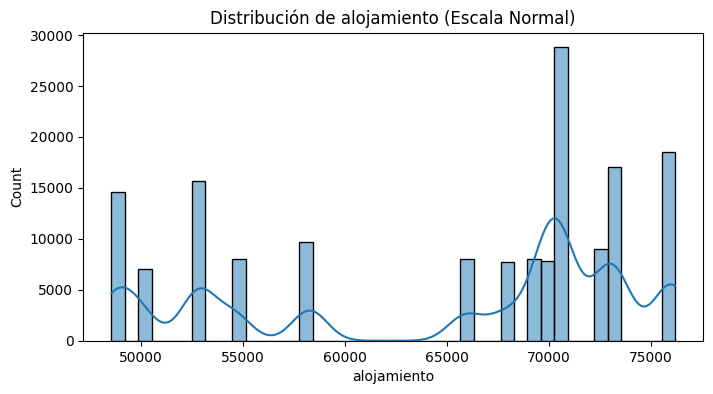

alojamiento - skewness> -0.59
alojamiento - Kurtosis> -1.25
------------------------------


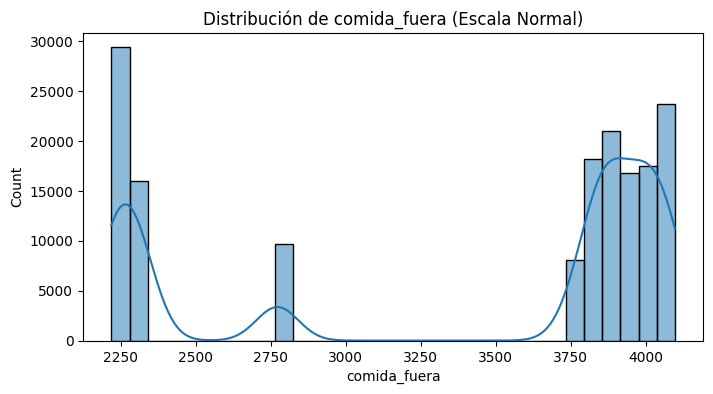

comida_fuera - skewness> -0.68
comida_fuera - Kurtosis> -1.42
------------------------------


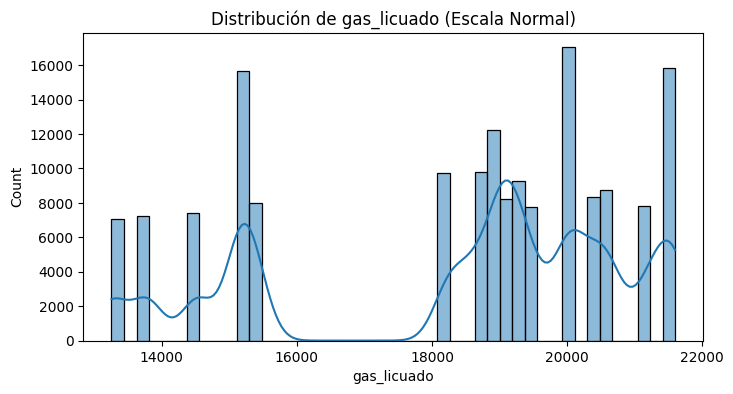

gas_licuado - skewness> -0.66
gas_licuado - Kurtosis> -0.92
------------------------------


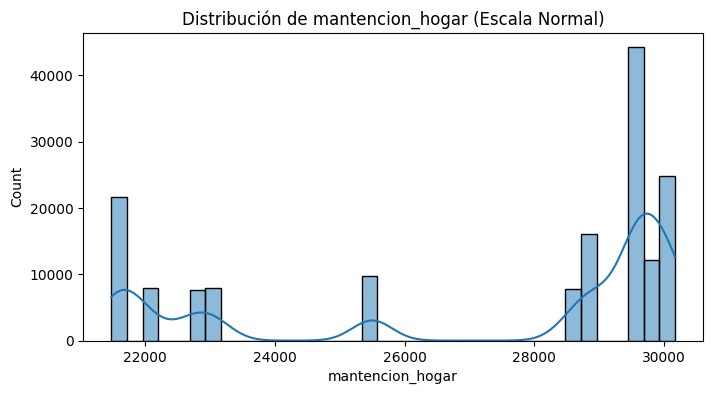

mantencion_hogar - skewness> -0.77
mantencion_hogar - Kurtosis> -1.23
------------------------------


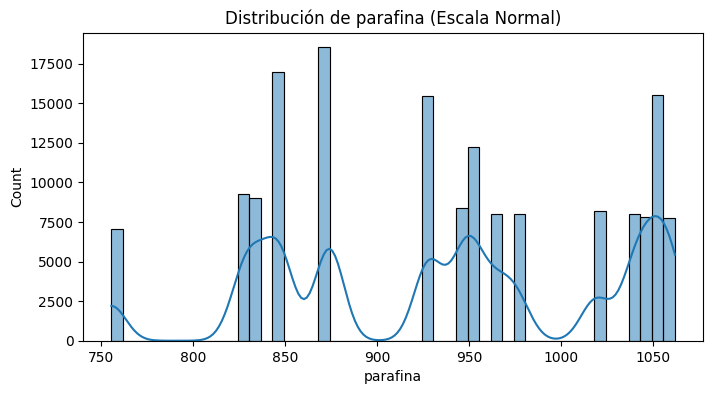

parafina - skewness> -0.13
parafina - Kurtosis> -1.06
------------------------------


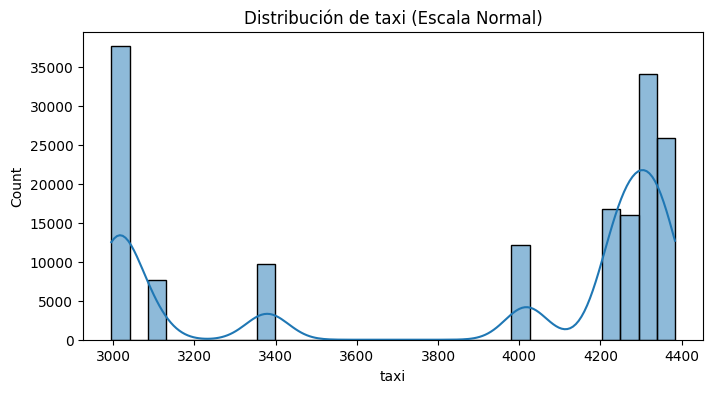

taxi - skewness> -0.65
taxi - Kurtosis> -1.45
------------------------------


In [6]:
variables_con_log = ['price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_ltm']# Agrega aquí las que se vean mal

for columna in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(8, 4))

    if columna in variables_con_log:
        sns.histplot(df[columna], kde=True)
        plt.title(f'Distribución de {columna} (Escala Logarítmica)')
    else:
        sns.histplot(df[columna], kde=True)
        plt.title(f'Distribución de {columna} (Escala Normal)')

    plt.show() 
    print(f'{columna} - skewness> {df[columna].skew():.2f}')
    print(f'{columna} - Kurtosis> {df[columna].kurt():.2f}')
    print('-'*30)


In [ ]:
plt.figure(figsize=(10,8))
correlation_matrix = df.select_dtypes(include=(np.number)).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Mapa de Calor de Correlaciones")
plt.show()

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns
results = []
alpha = 0.5

for i in range(len(categorical_columns)):
    for j in range(i + 1, len(categorical_columns)):
        col1 = categorical_columns[i]
        col2 = categorical_columns[j]
        contingency_table = pd.crosstab(df[col1], df[col2])
        chi2_stat, p, dof, expected = chi2_contingency(contingency_table)
        chi2_crit = chi2_dist.ppf(1 - alpha, dof)
        results.append((col1, col2, chi2_stat, chi2_crit, p))
        
chi_results_df = pd.DataFrame(
    results,
    columns=['Variable 1', 'Variable 2', 'Xi-cuadrado', 'Valor crítico', 'p-value']
)
print("Resultados de Ji-cuadrado (p-value < 0.05 indica relación significativa):")
display(chi_results_df)

# Modelos

In [7]:
train_df = df.sample(frac=0.8, random_state=42) # se utiliza la funcion de pandas para retornar solo el 80% de los datos
test_df = df.drop(train_df.index) # Se elimina el 80% de los datos para retornar el 20%


train_df = tfdf.keras.pd_dataframe_to_tf_dataset( # Transforma el dataset en un diccionario de tensores para que el modelo lo pueda entender mejor
    train_df,
    task = tfdf.keras.Task.REGRESSION,
    label = 'price',
)

test_df = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_df,
    task = tfdf.keras.Task.REGRESSION,
    label = 'price',
)

train_df = train_df.prefetch(tf.data.AUTOTUNE)

## Gradient Boost 
https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/GradientBoostedTreesModel

In [8]:
model = tfdf.keras.GradientBoostedTreesModel(
    task = tfdf.keras.Task.REGRESSION, # Indica el objetivo del modelo
    num_trees = 3000,
    max_depth = 30,
    growing_strategy = "BEST_FIRST_GLOBAL", # Indica que pare cuando encuentre el primer mejor optimo global
    shrinkage = 0.1, # Tasa de aprendizaje
    l2_regularization = 0.1 # Penaliza al modelo cuando los valores en las hojas del modelo son muy extremos
)
model.fit(train_df)

Use /tmp/tmp55364trc as temporary training directory
Reading training dataset...


W0000 00:00:1778972062.636658   46910 gradient_boosted_trees.cc:1873] "goss_alpha" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1778972062.636686   46910 gradient_boosted_trees.cc:1883] "goss_beta" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1778972062.636688   46910 gradient_boosted_trees.cc:1897] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training dataset read in 0:00:04.018724. Found 128055 examples.
Training model...


I0000 00:00:1778972066.689763   46910 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1778972066.689800   46910 kernel.cc:783] Collect training examples
I0000 00:00:1778972066.689813   46910 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: NUMERICAL
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1778972066.690417   46910 kernel.cc:401] Number of batches: 129
I0000 00:00:1778972066.690446   46910 kernel.cc:402] Number of examples: 128055
I0000 00:00:1778972066.736153   46910 data_spec_inference.cc:354] 3 item(s) have been pruned (i.e. they are considered out of dictionary) for the column nombre_estacion (118 item(s) left) because min_value_count=5 and max_number_of_unique_values=2000
I0000 00:00:1778972066.761263   46910 kernel.cc:802] Training dataset:
Number

Model trained in 0:01:45.576344
Compiling model...


I0000 00:00:1778972172.187470   46910 quick_scorer_extended.cc:927] The binary was compiled without AVX2 support, but your CPU supports it. Enable it for faster model inference.
I0000 00:00:1778972172.218149   46910 abstract_model.cc:1439] Engine "GradientBoostedTreesQuickScorerExtended" built
2026-05-16 18:56:12.218183: I tensorflow_decision_forests/tensorflow/ops/inference/kernel.cc:1035] Use fast generic engine


Model compiled.


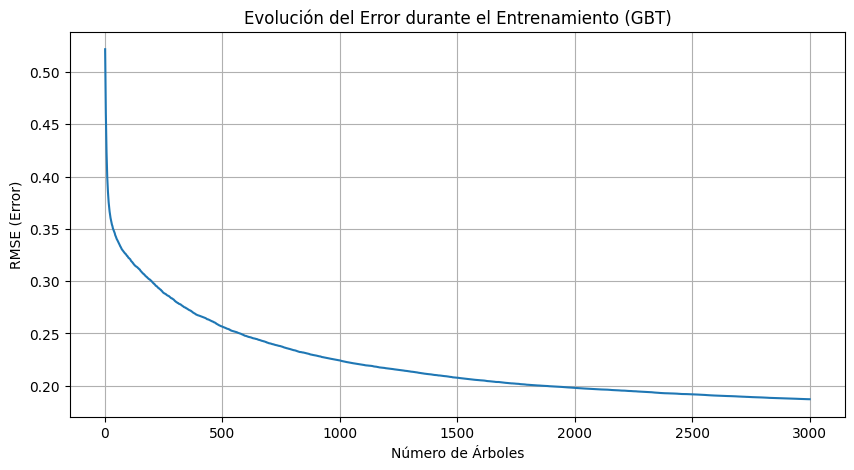

In [9]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(10, 5))
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel("Número de Árboles")
plt.ylabel("RMSE (Error)")
plt.title("Evolución del Error durante el Entrenamiento (GBT)")
plt.grid(True)
plt.show()

2026-05-16 18:59:22.586373: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


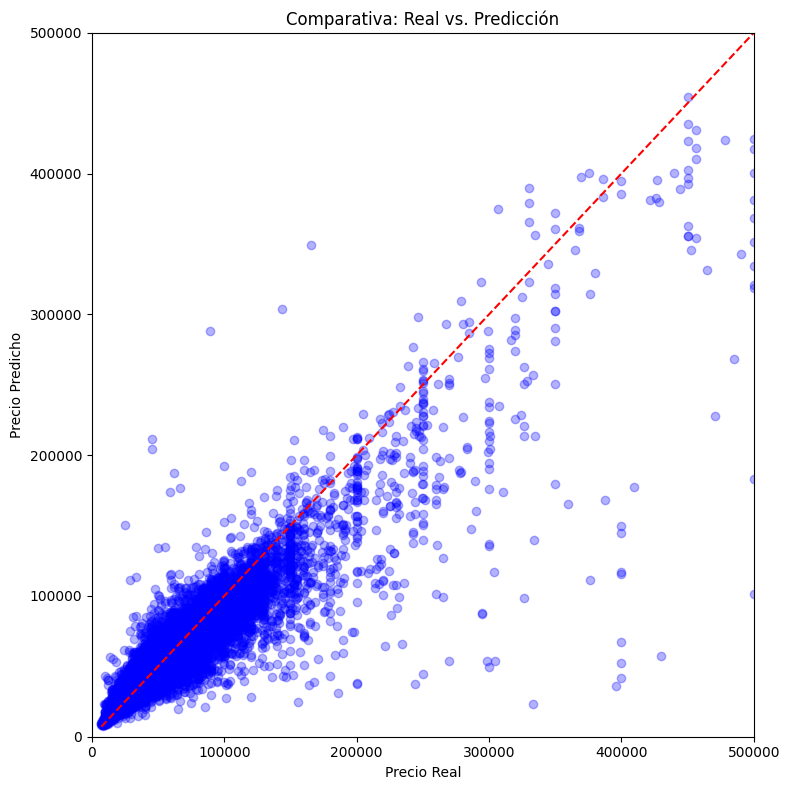

In [10]:
all_labels = []
all_preds = []

for features, labels in test_df:
    preds = model.predict(features, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds.flatten())

real_labels = np.expm1(all_labels)
real_preds = np.expm1(all_preds)

plt.figure(figsize=(8, 8))
plt.scatter(real_labels, real_preds, alpha=0.3, color='blue')
plt.plot([min(real_labels), max(real_labels)], [min(real_labels), max(real_labels)], color='red', linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Comparativa: Real vs. Predicción")

plt.xlim(0, 500000) 
plt.ylim(0, 500000)

plt.tight_layout()
plt.show()

/tmp/ipykernel_46910/1909013796.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')


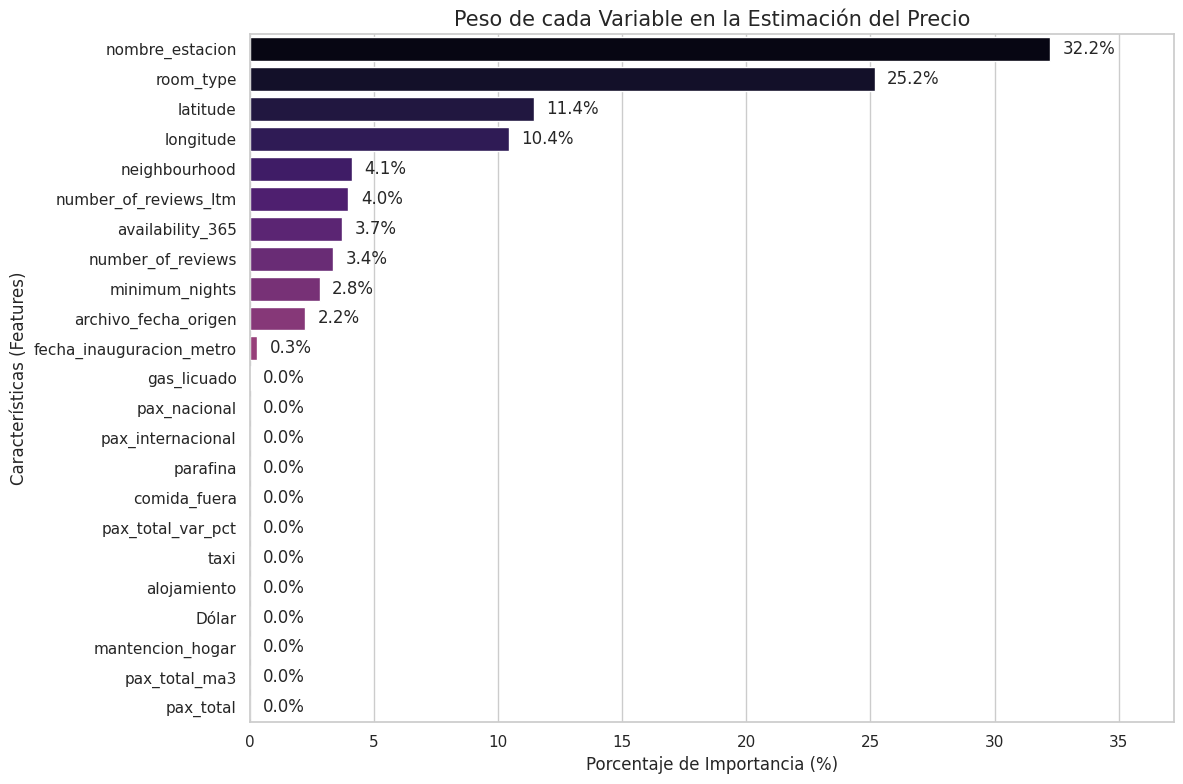

In [11]:
inspector = model.make_inspector()

# Utiliza la funcion variable_importance para ver que tanto aporto cada variable.
# Se utiliza SUM_SCORE para ver el score de cada variable
importances = inspector.variable_importances()["SUM_SCORE"] # Retorna un diccionario

feature_names = [i[0].name for i in importances] # Convertir el diccionario en una lista
feature_values = [i[1] for i in importances]

df_imp = pd.DataFrame({'Variable': feature_names, 'Valor': feature_values}) # Se transforma la lista en un Dataframe con columna variable y valor, las filas corresponderian a la importancia de las variables

# 4. Convertir a porcentaje (%)
df_imp['Porcentaje'] = (df_imp['Valor'] / df_imp['Valor'].sum()) * 100
df_imp = df_imp.sort_values(by='Porcentaje', ascending=False)


# Crear el gráfico
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')

# Añadir etiquetas de porcentaje al final de cada barra
for p in ax.patches: # patches es la barra de cada grafico
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 0.5, p.get_y() + p.get_height()/2), 
                va='center')

plt.title("Peso de cada Variable en la Estimación del Precio", fontsize=15)
plt.xlabel("Porcentaje de Importancia (%)")
plt.ylabel("Características (Features)")
plt.xlim(0, df_imp['Porcentaje'].max() + 5) # Espacio para el texto
plt.tight_layout()
plt.show()

## Random Forest Regressor
https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/RandomForestModel

In [13]:
model_rf = tfdf.keras.RandomForestModel(
    task = tfdf.keras.Task.REGRESSION,
    num_trees = 3000, 
    max_depth = 16, 
    growing_strategy = "BEST_FIRST_GLOBAL",
)
  
model_rf.fit(train_df) 

Use /tmp/tmpiu5trb4_ as temporary training directory
Reading training dataset...
Training dataset read in 0:00:00.811313. Found 128055 examples.
Training model...


I0000 00:00:1778972395.542182   46910 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1778972395.542207   46910 kernel.cc:783] Collect training examples
I0000 00:00:1778972395.542215   46910 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: NUMERICAL
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1778972395.542323   46910 kernel.cc:401] Number of batches: 129
I0000 00:00:1778972395.542331   46910 kernel.cc:402] Number of examples: 128055
I0000 00:00:1778972395.568613   46910 data_spec_inference.cc:354] 3 item(s) have been pruned (i.e. they are considered out of dictionary) for the column nombre_estacion (118 item(s) left) because min_value_count=5 and max_number_of_unique_values=2000
I0000 00:00:1778972395.584553   46910 kernel.cc:802] Training dataset:
Number

Model trained in 0:00:57.151282
Compiling model...


I0000 00:00:1778972452.673982   46910 decision_forest.cc:808] Model loaded with 3000 root(s), 183000 node(s), and 18 input feature(s).
I0000 00:00:1778972452.674020   46910 abstract_model.cc:1439] Engine "RandomForestGeneric" built
2026-05-16 19:00:52.674035: I tensorflow_decision_forests/tensorflow/ops/inference/kernel.cc:1035] Use fast generic engine


Model compiled.


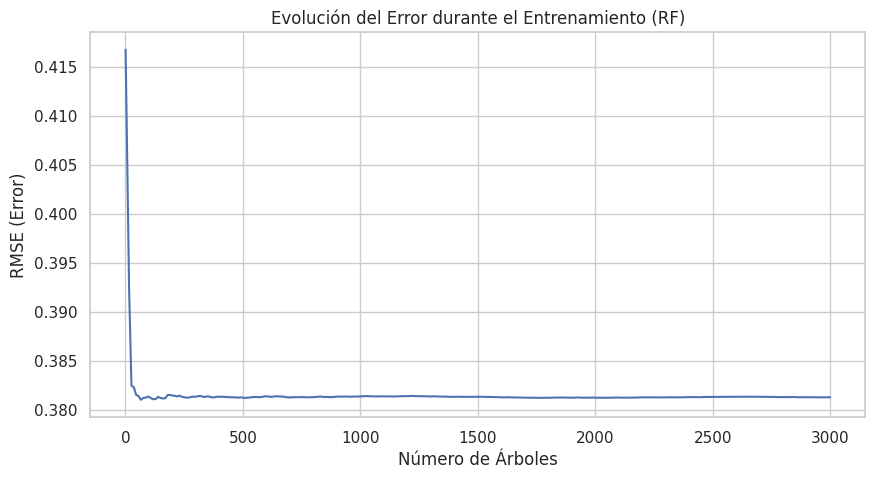

In [15]:
logs = model_rf.make_inspector().training_logs()

plt.figure(figsize=(10, 5))
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel("Número de Árboles")
plt.ylabel("RMSE (Error)")
plt.title("Evolución del Error durante el Entrenamiento (RF)")
plt.grid(True)
plt.show()

2026-05-16 19:02:11.264901: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


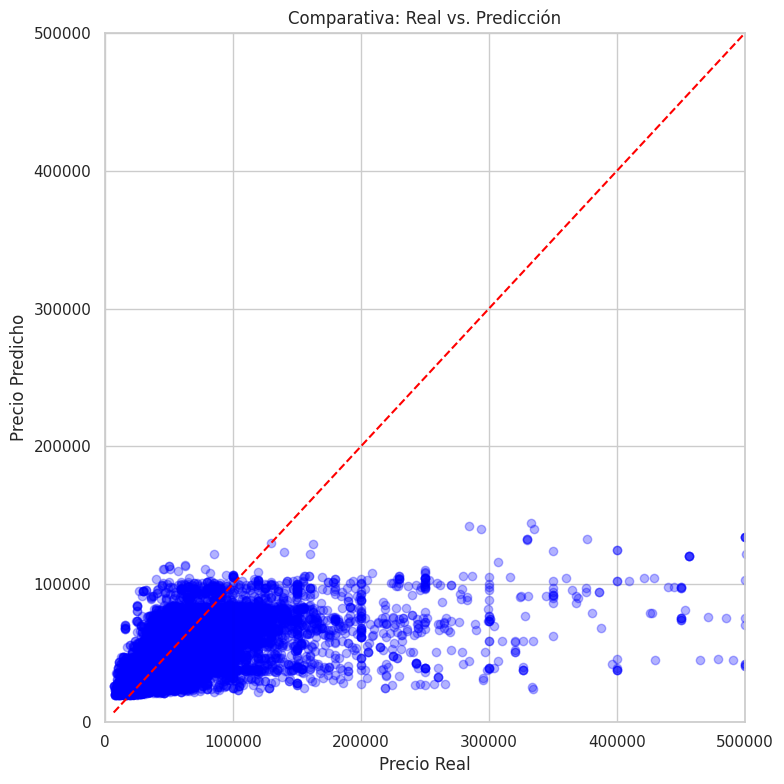

In [16]:
all_labels = []
all_preds = []

for features, labels in test_df:
    preds = model_rf.predict(features, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds.flatten())
    
real_labels = np.expm1(all_labels)
real_preds = np.expm1(all_preds)

# Graficar
plt.figure(figsize=(8, 8))
plt.scatter(real_labels, real_preds, alpha=0.3, color='blue')
plt.plot([min(real_labels), max(real_labels)], [min(real_labels), max(real_labels)], color='red', linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Comparativa: Real vs. Predicción")

# Limitar los ejes si tienes esos outliers de 100 millones
plt.xlim(0, 500000) 
plt.ylim(0, 500000)

plt.tight_layout()
plt.show()

/tmp/ipykernel_46910/4242983671.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')


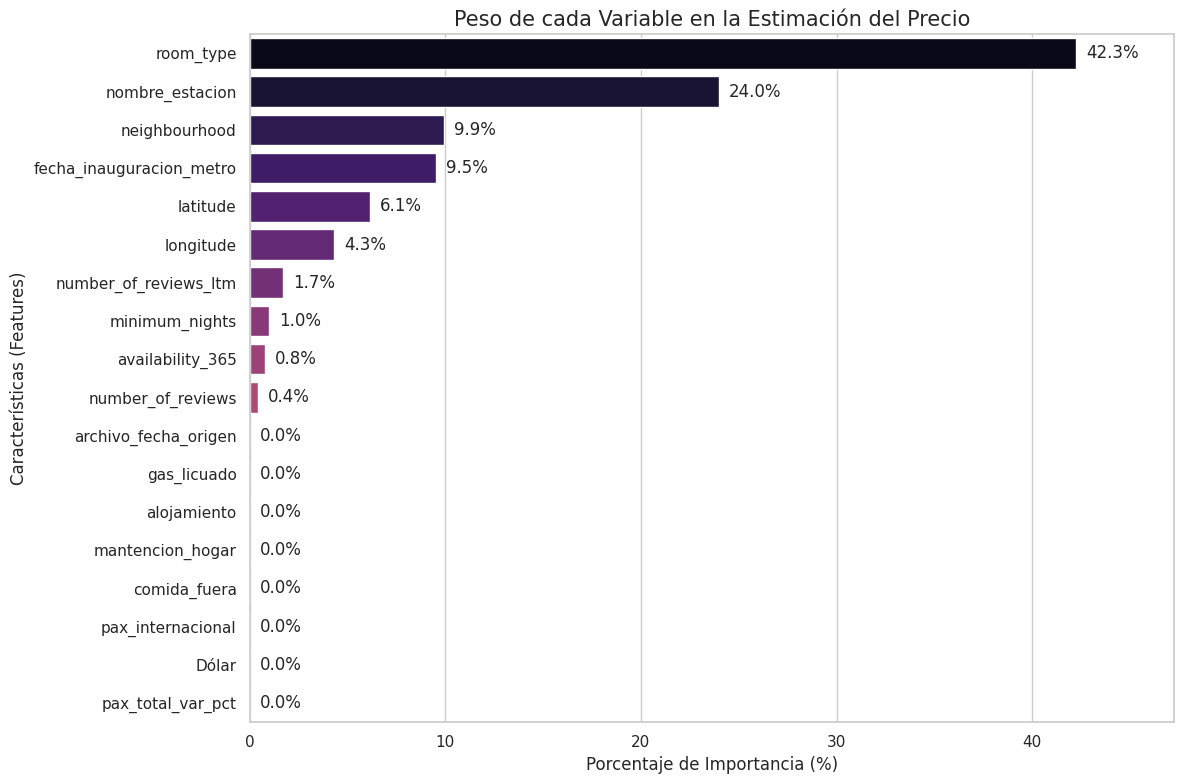

In [17]:
# 1. Obtener el inspector del modelo
inspector = model_rf.make_inspector()

# 2. Extraer la importancia (usualmente usamos 'SUM_SCORE' o 'MEAN_DECREASE_IN_ACCURACY')
# SUM_SCORE indica cuánto contribuyó cada variable a reducir la varianza del precio
importances = inspector.variable_importances()["SUM_SCORE"]

# 3. Convertir a un DataFrame de Pandas para manejar porcentajes
feature_names = [i[0].name for i in importances]
feature_values = [i[1] for i in importances]

df_imp = pd.DataFrame({'Variable': feature_names, 'Valor': feature_values})

# 4. Convertir a porcentaje (%)
df_imp['Porcentaje'] = (df_imp['Valor'] / df_imp['Valor'].sum()) * 100
df_imp = df_imp.sort_values(by='Porcentaje', ascending=False)


plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Crear el gráfico
ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')

# Añadir etiquetas de porcentaje al final de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 0.5, p.get_y() + p.get_height()/2), 
                va='center')

plt.title("Peso de cada Variable en la Estimación del Precio", fontsize=15)
plt.xlabel("Porcentaje de Importancia (%)")
plt.ylabel("Características (Features)")
plt.xlim(0, df_imp['Porcentaje'].max() + 5) # Espacio para el texto
plt.tight_layout()
plt.show()

## Deep Neural Network

In [18]:
columnas_categoricas = ['neighbourhood', 'room_type', 'nombre_estacion']

df_procesado = pd.get_dummies(df, columns=columnas_categoricas)

In [19]:
df_procesado['archivo_fecha_origen'] = pd.to_datetime(df_procesado['archivo_fecha_origen'])
df_procesado['fecha_inauguracion_metro'] = pd.to_datetime(df_procesado['fecha_inauguracion_metro'])

# 2. Creamos nuevas columnas numéricas para el modelo
# Extraemos el año
df_procesado['archivo_fecha_origen_year'] = df_procesado['archivo_fecha_origen'].dt.year
df_procesado['fecha_inauguracion_metro_year'] = df_procesado['fecha_inauguracion_metro'].dt.year

# Extraemos el mes (muy útil para capturar temporadas altas en Airbnb)
df_procesado['archivo_fecha_origen_month'] = df_procesado['archivo_fecha_origen'].dt.month
df_procesado['fecha_inauguracion_metro_month'] = df_procesado['fecha_inauguracion_metro'].dt.month

# 3. Eliminamos las columnas originales de texto/fecha
# Ya no las necesitamos porque el modelo no las puede procesar
df_procesado = df_procesado.drop(['archivo_fecha_origen', 'fecha_inauguracion_metro'], axis=1)

print("Transformación de fechas completada.")
print(df_procesado)

Transformación de fechas completada.
         latitude  longitude    price  minimum_nights  number_of_reviews  \
0      -33.437666 -70.646033  10.5967          0.6931             1.0986   
1      -33.469590 -70.626490   9.6063          1.3863             1.9459   
2      -33.454630 -70.659130  10.1823          1.3863             0.6931   
3      -33.451410 -70.643540   9.9988          1.3863             4.3820   
4      -33.395420 -70.548520  11.3504          2.0794             4.1431   
...           ...        ...      ...             ...                ...   
160064 -33.408490 -70.549390  11.6728          1.3863             2.1972   
160065 -33.458130 -70.669446  10.8348          1.0986             0.6931   
160066 -33.456201 -70.571530  10.8097          0.6931             2.3979   
160067 -33.437268 -70.645229  10.8968          0.6931             1.3863   
160068 -33.429590 -70.618800  10.7643          0.6931             3.8286   

        availability_365  number_of_reviews_ltm  D

In [ ]:
df_procesado = df_procesado.dropna()

In [ ]:
df_procesado.info()

In [20]:
y = df_procesado['price']
x = df_procesado.drop(['price'], axis=1) # Se elimina la columna price y el resultado de eso se retorna a la variable x

# Separar los datos en train, validation, testing
x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.01, random_state=42) #This return a data frame type
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.01, random_state=42)

scaler = StandardScaler()  # Se crea la variables StandardScaler para estandarizar las variables

x_train_scaled = scaler.fit_transform(x_train) # Se utiliza la variable fit_transform para normalizar los datos de x_train
x_val_scaled = scaler.transform(x_val)

print(x_train_scaled)
# Crear Dataset para optimizar TF
# Se utilizara la funcion from_tensor_slices la cual transformara los datos en objetos tf.data.Dataset
# A su vez crea un flujo para que los datos se vayan agregando a la tarjeta de video uno a la vez.
train_ds = tf.data.Dataset.from_tensor_slices((x_train_scaled, y_train.values))
val_ds = tf.data.Dataset.from_tensor_slices((x_val_scaled, y_val.values))

# Optimizar Datasets
# Se utiliza shuffle para desordenar los datos en cada epoca
# batch agrupa los datos para que cada x cantidad de datos se cambien los pesos
# prefetch hace que mientras se estan entrenando datos, se este preparando el siguiente grupo
train_ds = train_ds.shuffle(buffer_size=10000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

[[-0.61003817 -0.41218722  0.141387   ...  1.6750367   0.73430333
  -1.23333558]
 [-0.70037761 -1.71518667  0.141387   ... -1.17590299 -2.08621564
   1.05088735]
 [ 2.65182814  2.96463034 -0.96387884 ...  1.09188994  0.42091234
  -1.23333558]
 ...
 [-0.04099115 -0.17909733 -0.96387884 ... -1.04631482  0.73430333
  -0.66227985]
 [-0.1134711  -0.55129335 -0.96387884 ...  0.44394911  1.36108533
  -0.66227985]
 [ 0.69845957  0.72581856 -0.96387884 ... -0.85193257  1.04769433
   0.76535948]]


In [21]:
input_columns = x_train.shape[1]
model_mlp = keras.Sequential(
    [
        layers.Dense(256, activation="relu", input_shape=(input_columns,), name="layer1"),
        layers.BatchNormalization(), # Esto normaliza los datos para que haya una media cercana a 0 y una desviacion estandar cercana a 1
        layers.Dense(128, activation="relu", name="layer2"),
        layers.Dense(64, name="layer3"),
        layers.Dense(1)
    ]
)
model_mlp.summary()

/home/branco/anaconda3/envs/IA/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 256)            │        45,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,809 (343.00 KB)

 Trainable params: 87,297 (341.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
print(input_columns)

In [22]:
model_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='mean_squared_error',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError()], # se utiliza mae para ver la diferencia real en precio a la que se esta
)

history = model_mlp.fit(
    train_ds,
    validation_data = val_ds,
    epochs=50,
    verbose = 1 # Para ver en terminal como va el entrenamiento
)

Epoch 1/50
4903/4903 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 2.1842 - mae: 0.7925 - root_mean_squared_error: 1.4779 - val_loss: 1.2648 - val_mae: 0.8292 - val_root_mean_squared_error: 1.1246
Epoch 2/50
4903/4903 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.3092 - mae: 0.4271 - root_mean_squared_error: 0.5561 - val_loss: 0.8621 - val_mae: 0.6599 - val_root_mean_squared_error: 0.9285
Epoch 3/50
4903/4903 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.2371 - mae: 0.3715 - root_mean_squared_error: 0.4869 - val_loss: 0.4986 - val_mae: 0.4514 - val_root_mean_squared_error: 0.7061
Epoch 4/50
4903/4903 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.2042 - mae: 0.3422 - root_mean_squared_error: 0.4518 - val_loss: 0.3754 - val_mae: 0.3612 - val_root_mean_squared_error: 0.6127
Epoch 5/50
4903/4903 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.1863 - mae: 0.3258 - root_mean_squared_error: 0.4316 - val_loss: 0.3109 - val_mae: 0.3411 - val_root_mean_squared_error: 0.5576
Epoch 6/50
4903/4903 ━━━━━━━━━━━━━━━━━━━

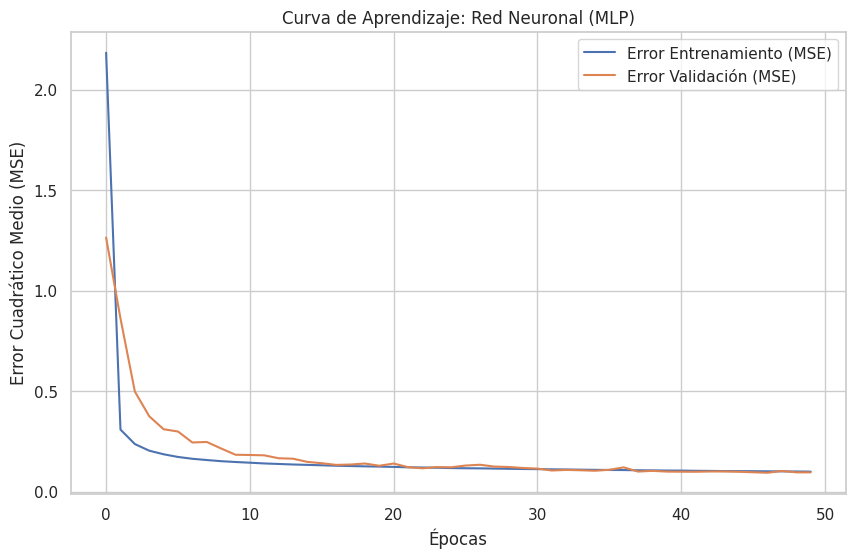

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Error Validación (MSE)')
plt.title('Curva de Aprendizaje: Red Neuronal (MLP)')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
x_test_scaled = scaler.transform(x_test)
test_ds = tf.data.Dataset.from_tensor_slices((x_test_scaled, y_test.values))
test_ds = test_ds.batch(32)

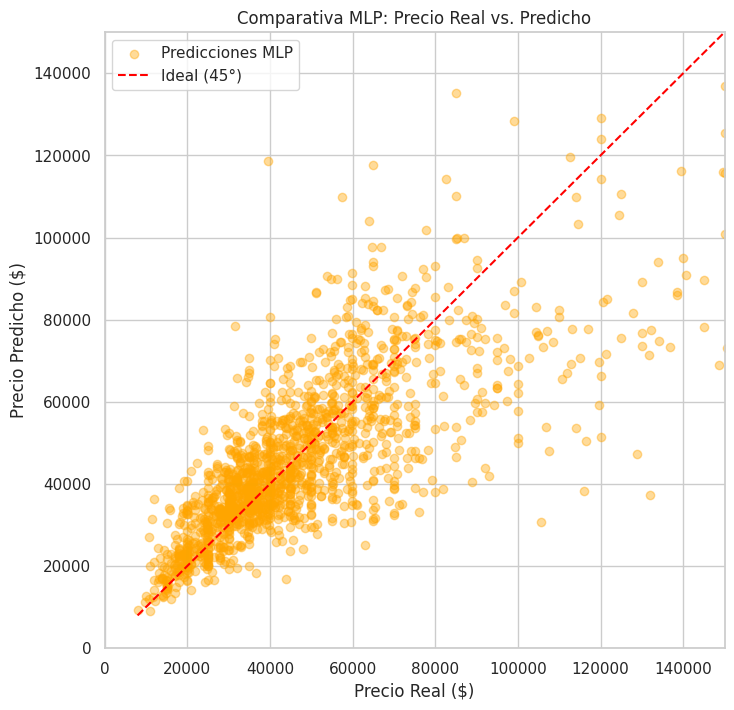

In [25]:
all_labels = []
all_preds = []

for features, labels in test_ds:
    preds = model_mlp.predict(features, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds.flatten())
    
real_labels = np.expm1(all_labels)
real_preds = np.expm1(all_preds)

plt.figure(figsize=(8, 8))
plt.scatter(real_labels, real_preds, alpha=0.4, color='orange', label='Predicciones MLP')
plt.plot([min(real_labels), max(real_labels)], [min(real_labels), max(real_labels)], color='red', linestyle='--', label='Ideal (45°)')
plt.title('Comparativa MLP: Precio Real vs. Predicho')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.legend()
plt.xlim(0, 150000) # Ver solo hasta 300 mil pesos
plt.ylim(0, 150000)
plt.show()

/tmp/ipykernel_46910/1477908633.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Categoria_Consolidada', data=df_final, palette='viridis')


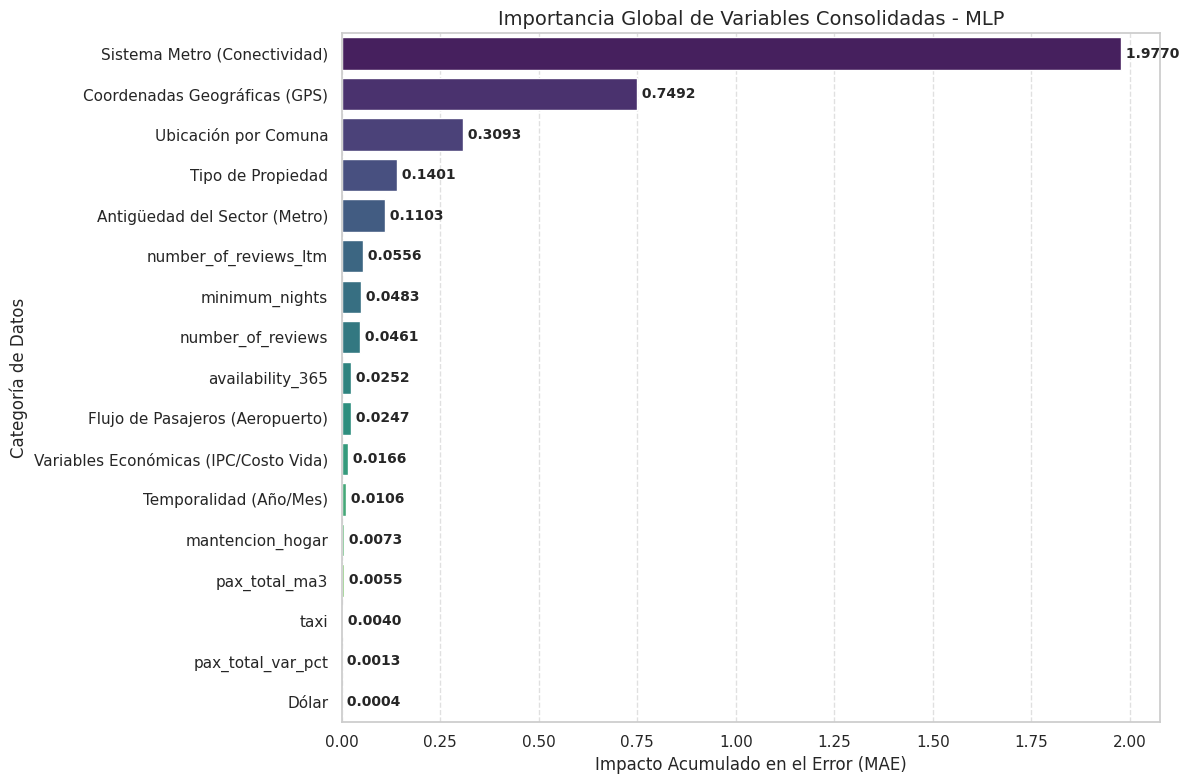

In [26]:
X_sample = x_test_scaled[:5000]
y_sample = y_test.values[:5000]

baseline_preds = model_mlp.predict(X_sample, verbose=0)
baseline_mae = mean_absolute_error(y_sample, baseline_preds)

importances = []
feature_names = x_test.columns 

for i in range(X_sample.shape[1]):
    # Guardamos la columna original
    save_col = X_sample[:, i].copy()
    
    # Desordenamos la columna i
    np.random.shuffle(X_sample[:, i])
    
    # Medimos el nuevo error
    shuffled_preds = model_mlp.predict(X_sample, verbose=0)
    shuffled_mae = mean_absolute_error(y_sample, shuffled_preds)
    
    # La importancia es cuánto aumentó el error (en pesos o log-puntos)
    importances.append(shuffled_mae - baseline_mae)
    
    # Restauramos la columna original para la siguiente iteración
    X_sample[:, i] = save_col

# 2. Crear tabla y graficar
df_todas = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})

# 2. Definimos la función de mapeo para agrupar las 179 columnas
def mapear_categoria(nombre):
    if 'nombre_estacion_' in nombre:
        return 'Sistema Metro (Conectividad)'
    elif 'neighbourhood_' in nombre:
        return 'Ubicación por Comuna'
    elif 'room_type_' in nombre:
        return 'Tipo de Propiedad'
    elif 'archivo_fecha_origen_' in nombre:
        return 'Temporalidad (Año/Mes)'
    elif 'fecha_inauguracion_metro_' in nombre:
        return 'Antigüedad del Sector (Metro)'
    elif nombre in ['latitude', 'longitude']:
        return 'Coordenadas Geográficas (GPS)'
    elif nombre in ['pax_internacional', 'pax_nacional', 'pax_total']:
        return 'Flujo de Pasajeros (Aeropuerto)'
    elif nombre in ['alojamiento', 'comida_fuera', 'gas_licuado', 'parafina']:
        return 'Variables Económicas (IPC/Costo Vida)'
    else:
        # Para variables únicas como 'minimum_nights', 'Dólar', 'availability_365', etc.
        return nombre 

# 3. Aplicamos el agrupamiento a las 179 filas
df_todas['Categoria_Consolidada'] = df_todas['Variable'].apply(mapear_categoria)

# 4. Sumamos las importancias de cada grupo
# Esto es vital: suma el impacto de las 100+ estaciones en una sola métrica
df_final = df_todas.groupby('Categoria_Consolidada')['Importancia'].sum().reset_index()

# 5. Ordenamos de mayor a menor para que el gráfico sea legible
df_final = df_final.sort_values(by='Importancia', ascending=False)

# 6. Graficamos el 100% de tus datos agrupados
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Categoria_Consolidada', data=df_final, palette='viridis')

# Añadimos los valores exactos al final de cada barra para mayor precisión técnica
for i, val in enumerate(df_final['Importancia']):
    plt.text(val, i, f' {val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.title('Importancia Global de Variables Consolidadas - MLP', fontsize=14)
plt.xlabel('Impacto Acumulado en el Error (MAE)', fontsize=12)
plt.ylabel('Categoría de Datos', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()